# Phase-amplitude coupling (PAC) — narrative tutorial

`scitex_nn.PAC` chains the package's bandpass bank, `Hilbert`, and
`ModulationIndex` into a single `nn.Module`. This notebook walks
through every step of that pipeline on a synthetic signal so the
comodulogram you get out the other end is unambiguous.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

import scitex_nn

torch.manual_seed(0)
rng = np.random.default_rng(0)

## 1 · Build a synthetic theta-gamma coupled signal

The classic textbook PAC: a low-frequency theta wave whose phase
modulates the amplitude of a high-frequency gamma carrier. We make
the modulation strong (depth 0.8) so the coupling is unambiguous.

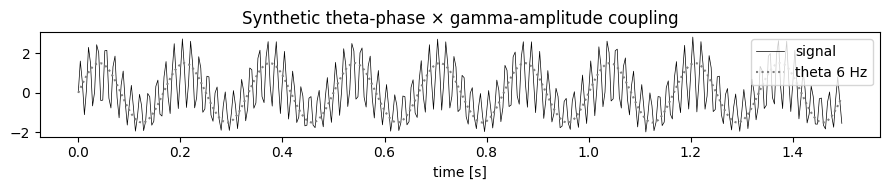

In [2]:
fs = 250
duration = 4.0
seq_len = int(fs * duration)
t = np.arange(seq_len) / fs

pha_freq, amp_freq = 6.0, 60.0
theta = np.sin(2 * np.pi * pha_freq * t)
envelope = 1 + 0.8 * (theta + 1) / 2
gamma = envelope * np.sin(2 * np.pi * amp_freq * t)
sig = (theta + gamma + 0.05 * rng.standard_normal(seq_len)).astype(np.float32)

fig, ax = plt.subplots(figsize=(9, 2.0))
n_show = int(1.5 * fs)
ax.plot(t[:n_show], sig[:n_show], "k", lw=0.5, label="signal")
ax.plot(
    t[:n_show], theta[:n_show] * 1.5, "grey", ls=":", label=f"theta {pha_freq:.0f} Hz"
)
ax.legend(loc="upper right")
ax.set_xlabel("time [s]")
ax.set_title("Synthetic theta-phase × gamma-amplitude coupling")
fig.tight_layout()
plt.show()

## 2 · Run `scitex_nn.PAC` end-to-end

Constructor takes the signal length and sample rate; the band
definitions can be tuned (or left at their defaults of 50 phase
bands across 2-20 Hz and 30 amplitude bands across 60-160 Hz).
Forward returns the comodulogram per (batch, channel).

In [3]:
x = torch.from_numpy(sig).view(1, 1, -1)
pac = scitex_nn.PAC(
    seq_len=seq_len,
    fs=fs,
    pha_start_hz=2,
    pha_end_hz=20,
    pha_n_bands=12,
    amp_start_hz=30,
    amp_end_hz=100,
    amp_n_bands=16,
    fp16=False,
)
como = pac(x).squeeze().detach().float().numpy()
pha_mids = pac.PHA_MIDS_HZ.numpy()
amp_mids = pac.AMP_MIDS_HZ.numpy()

print(f"comodulogram shape: {como.shape}")
print(f"max MI: {como.max():.4f}")

comodulogram shape: (12, 16)
max MI: 0.0466


## 3 · Read the comodulogram

Hot pixel = strong coupling between the row's phase frequency and
the column's amplitude frequency. The peak should be near the
(6 Hz, 60 Hz) coupling we built in.

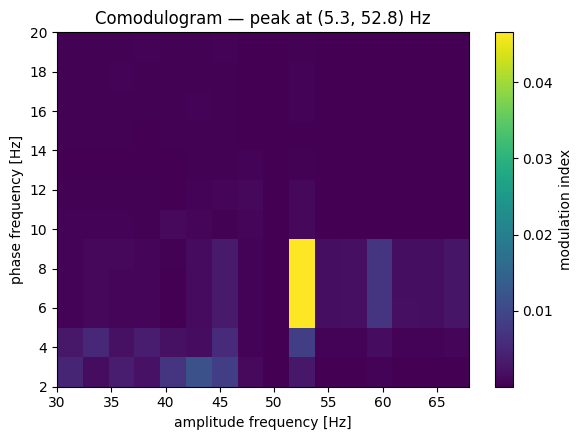

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(
    como,
    aspect="auto",
    origin="lower",
    extent=(amp_mids[0], amp_mids[-1], pha_mids[0], pha_mids[-1]),
    cmap="viridis",
)
fig.colorbar(im, ax=ax, label="modulation index")
peak_pha = pha_mids[int(np.argmax(como.max(axis=1)))]
peak_amp = amp_mids[int(np.argmax(como.max(axis=0)))]
ax.set_xlabel("amplitude frequency [Hz]")
ax.set_ylabel("phase frequency [Hz]")
ax.set_title(f"Comodulogram — peak at ({peak_pha:.1f}, {peak_amp:.1f}) Hz")
fig.tight_layout()
plt.show()

## 4 · What's inside `PAC`?

The `PAC` module is just three parts wired together:

1. `bandpass` — `BandPassFilter` (or `DifferentiableBandPassFilter`
   if `trainable=True`). Runs every (phase + amplitude) band.
2. `hilbert` — `Hilbert` extracts the analytic signal per band.
3. `Modulation_index` — `ModulationIndex` reduces phase × amplitude
   histograms to KL-divergence vs uniform.

Each piece is independently exported (`scitex_nn.BandPassFilter`,
`scitex_nn.Hilbert`, `scitex_nn.ModulationIndex`); compose them
yourself if you need to swap, e.g. a different bandpass design.

In [5]:
# Round-trip sanity check: re-running gives the same comodulogram.
como2 = pac(x).squeeze().detach().float().numpy()
assert np.allclose(como, como2), "PAC is not deterministic — investigate"
print("PAC is deterministic ✓")

PAC is deterministic ✓


## Where to next?

- `examples/09_modulation_index.py` — the underlying `ModulationIndex`
  on a single (phase, amplitude) pair.
- `examples/06b_differentiable_bandpass.py` — make the bandpass
  centres learnable (`trainable=True`).
- `examples/00_run_all.sh` — dispatch every numbered example.